In [19]:
"""
Program to cross-match SExtractor catalogs with Pan-STARRS DR1.
"""

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Reader Functions ----------- ###

def _get_column_names(read_line_object: List) -> List:
    """Reads the header info of the SExtractor catalog."""
    header = [line.split()[2] for line in read_line_object if line[0] == '#']
    return header

def _get_rows(read_line_object: List) -> List:
    """Reads the data rows from the SExtractor catalog."""
    data = [list(map(float, line.split())) for line in read_line_object if line[0] != '#']
    return data

def split_names_and_data(read_line_object: List) -> Tuple[List, List]:
    """Splits header and data rows."""
    header = _get_column_names(read_line_object)
    data = _get_rows(read_line_object)
    return header, data

def read_cat(sextractor_catalog: str) -> DataFrame:
    """Reads in a SExtractor catalog file and returns a DataFrame."""
    with open(sextractor_catalog, encoding='utf8') as file:
        lines = file.readlines()
    column_names, data = split_names_and_data(lines)
    data_frame = DataFrame(data, columns=column_names)
    return data_frame

### ----------- Cross-match Function ----------- ###

def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """Cross-match two sets of sky coordinates using astropy."""
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_separation = 1.0 * u.arcsec
    separation_constraint = d2d < max_separation
    matched_idx_decam = np.where(separation_constraint)[0]
    matched_idx_panstars = idx[separation_constraint]
    return matched_idx_decam, matched_idx_panstars

### ----------- CatalogMatcher Class ----------- ###

class CatalogMatcher:
    """Handles matching SExtractor catalogs with Pan-STARRS DR1."""

    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str):
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

    def match_catalogs(self):
        """Cross-match SExtractor and Pan-STARRS DR1 catalogs based on RA/Dec."""

        # Extract DECam coordinates
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        # Extract Pan-STARRS i-band coordinates
        ra_panstars = np.array(self.panstarrs_catalog['ira'])
        dec_panstars = np.array(self.panstarrs_catalog['idec'])

        # Filter out invalid entries
        valid_mask = (dec_panstars > -90) & (dec_panstars < 90) & (ra_panstars >= 0) & (ra_panstars <= 360)
        ra_panstars = ra_panstars[valid_mask]
        dec_panstars = dec_panstars[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Perform cross-match
        idx_decam, idx_panstars = cross_match(ra_decam, dec_decam, ra_panstars, dec_panstars)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_panstars].reset_index(drop=True)

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        """Save matched catalogs to disk."""
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam to: {decam_out}")
        print(len(matched_decam), "matched DECam entries.")
        print(f"Saved matched Pan-STARRS to: {pan_out}")

### ----------- Script Entry Point ----------- ###

if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_new.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/Pannstar_casjobs.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


Saved matched DECam to: /Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat
79556 matched DECam entries.
Saved matched Pan-STARRS to: /Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv


In [20]:
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from typing import List, Tuple
from pandas import DataFrame

### ----------- SExtractor Catalog Reader ----------- ###
def _get_column_names(lines: List[str]) -> List[str]:
    """Extract column names from SExtractor catalog header lines starting with #."""
    header = [line.split()[2] for line in lines if line.startswith('#')]
    return header

def _get_rows(lines: List[str]) -> List[List[float]]:
    """Extract numerical data rows (non-header) from SExtractor catalog."""
    data = [list(map(float, line.split())) for line in lines if not line.startswith('#')]
    return data

def split_names_and_data(lines: List[str]) -> Tuple[List[str], List[List[float]]]:
    """Split lines into header columns and data rows."""
    header = _get_column_names(lines)
    data = _get_rows(lines)
    return header, data

def read_cat(sextractor_catalog_path: str) -> DataFrame:
    """Read SExtractor catalog into a pandas DataFrame."""
    with open(sextractor_catalog_path, encoding='utf8') as f:
        lines = f.readlines()
    colnames, data = split_names_and_data(lines)
    df = DataFrame(data, columns=colnames)
    return df

### ----------- Cross-match Function ----------- ###
def cross_match(ra_new: np.array, dec_new: np.array, ra_catalog: np.array, dec_catalog: np.array):
    """
    Cross-match two catalogs by sky coordinates within 2 arcsec using astropy.
    Returns indices in new catalog and catalog matched arrays.
    """
    c_new = SkyCoord(ra=ra_new * u.deg, dec=dec_new * u.deg)
    c_catalog = SkyCoord(ra=ra_catalog * u.deg, dec=dec_catalog * u.deg)
    idx, d2d, _ = c_new.match_to_catalog_sky(c_catalog)
    max_sep = 1.0 * u.arcsec
    sep_constraint = d2d < max_sep
    matched_idx_new = np.where(sep_constraint)[0]
    matched_idx_catalog = idx[sep_constraint]
    return matched_idx_new, matched_idx_catalog

### ----------- Catalog Matcher Class ----------- ###
class CatalogMatcher:
    def __init__(self, sextractor_cat_path: str, panstarrs_csv_path: str, band: str = 'i', threshold: float = 0.05):
        # Read catalogs
        self.sextractor_catalog = read_cat(sextractor_cat_path)
        self.panstarrs_catalog = pd.read_csv(panstarrs_csv_path)

        # Filter Pan-STARRS catalog to stars only using PSF-Kron magnitude difference
        psf_col = f"{band}PSFMag"
        kron_col = f"{band}KronMag"
        if psf_col not in self.panstarrs_catalog.columns or kron_col not in self.panstarrs_catalog.columns:
            raise ValueError(f"Pan-STARRS catalog missing required columns: {psf_col} or {kron_col}")
        
        star_mask = np.abs(self.panstarrs_catalog[psf_col] - self.panstarrs_catalog[kron_col]) < threshold
        self.panstarrs_catalog = self.panstarrs_catalog[star_mask].reset_index(drop=True)
        print(f"Stars selected in Pan-STARRS: {len(self.panstarrs_catalog)} entries")

    def match_catalogs(self):
        # Extract coordinates from DECam catalog (SExtractor)
        ra_decam = np.array(self.sextractor_catalog['ALPHAPEAK_J2000'])
        dec_decam = np.array(self.sextractor_catalog['DELTAPEAK_J2000'])

        # Extract coordinates from filtered Pan-STARRS catalog
        ra_pan = np.array(self.panstarrs_catalog['ira'])
        dec_pan = np.array(self.panstarrs_catalog['idec'])

        # Clean invalid coordinates from Pan-STARRS
        valid_mask = (dec_pan > -90) & (dec_pan < 90) & (ra_pan >= 0) & (ra_pan <= 360)
        ra_pan = ra_pan[valid_mask]
        dec_pan = dec_pan[valid_mask]
        filtered_panstars = self.panstarrs_catalog[valid_mask].reset_index(drop=True)

        # Cross-match catalogs within 2 arcsec
        idx_decam, idx_pan = cross_match(ra_decam, dec_decam, ra_pan, dec_pan)

        matched_decam = self.sextractor_catalog.iloc[idx_decam].reset_index(drop=True)
        matched_panstars = filtered_panstars.iloc[idx_pan].reset_index(drop=True)

        print(f"Matched {len(matched_decam)} DECam sources with Pan-STARRS stars.")

        return matched_decam, matched_panstars

    def save_matches(self, matched_decam, matched_panstars,
                     decam_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat',
                     pan_out='/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'):
        matched_decam.to_csv(decam_out, index=False)
        matched_panstars.to_csv(pan_out, index=False)
        print(f"Saved matched DECam catalog to: {decam_out}")
        print(f"Saved matched Pan-STARRS catalog to: {pan_out}")

### ----------- Main Execution ----------- ###
if __name__ == '__main__':
    SEX_CATALOG_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_new.cat'
    PANSTARRS_PATH = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'

    matcher = CatalogMatcher(SEX_CATALOG_PATH, PANSTARRS_PATH, band='i', threshold=0.05)
    matched_decam, matched_panstars = matcher.match_catalogs()
    matcher.save_matches(matched_decam, matched_panstars)


Stars selected in Pan-STARRS: 8812 entries
Matched 8814 DECam sources with Pan-STARRS stars.
Saved matched DECam catalog to: /Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat
Saved matched Pan-STARRS catalog to: /Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv


In [6]:
print("Original Pan-STARRS entries:", len(pd.read_csv(PANSTARRS_PATH)))
print("Filtered Pan-STARRS stars (i-band):", len(SEX_CATALOG_PATH))


Original Pan-STARRS entries: 79556
Filtered Pan-STARRS stars (i-band): 60


Slope (alpha):     0.87677 ± 0.00236
Intercept (zpt):   28.98460 ± 0.00047

K correction:      -0.15385
ZPT prime:         29.13845
3275 data points after clipping.


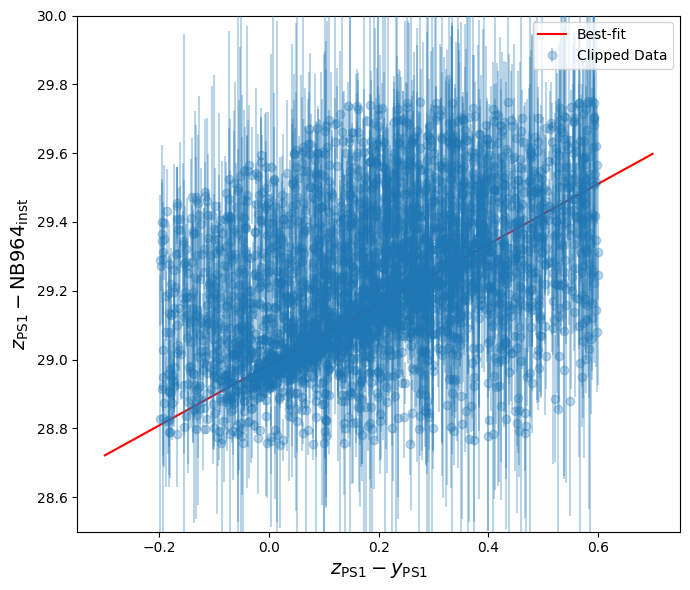

In [22]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping ----------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_AUTO'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_AUTO']

# ---------- Remove Bad Data ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ---------- Final Linear Fit ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Compute Fit & Bands ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)



# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)



# Best Fit Line
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)

# Data Points
plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', alpha=0.3, label='Clipped Data', zorder=4)
print(len(delta_pan_clipped), "data points after clipping.")

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_cutfit_conf_scatter.png', dpi=300)
plt.show()


Slope (alpha):     0.85031 ± 0.00847
Intercept (zpt):   28.88073 ± 0.00124

K correction:      -0.00147
ZPT prime:         28.88220

Chi-squared:       3129.74
DOF:               4072
Reduced Chi²:      0.77
4074 data points after clipping.


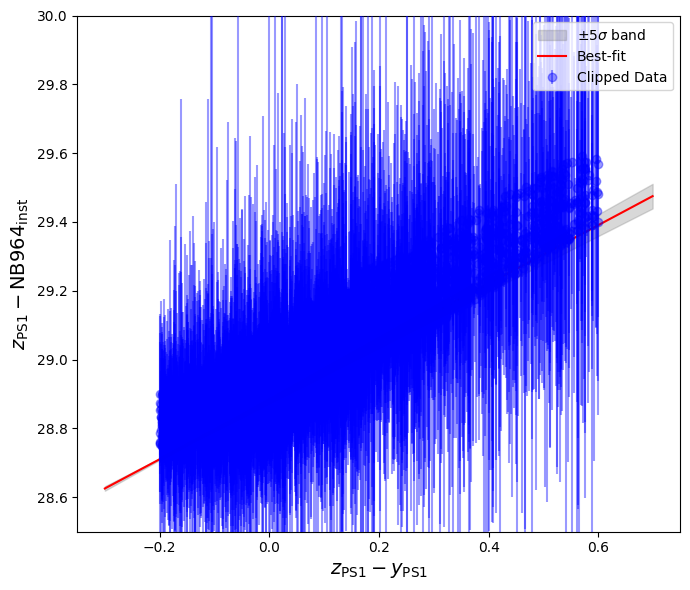

In [20]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping ----------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- Outlier Limits ----------
def bottom_limit(x_val):
    """Lower limit to remove outliers."""
    m = 1
    c = 28.8
    return m * x_val + c

def upper_limit(x_val):
    """Upper limit to remove outliers."""
    m = 1
    c = 29.1
    return m * x_val + c

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 2
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ---------- Remove Bad Data ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- Remove Outliers with Limits ----------
outlier_mask = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[outlier_mask]
delta_decam = delta_decam[outlier_mask]
delta_pan_err = delta_pan_err[outlier_mask]
delta_decam_err = delta_decam_err[outlier_mask]

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ---------- Final Linear Fit ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Chi-Square Goodness of Fit ----------
model_vals = straight_line(delta_pan_clipped, *popt)
residuals = delta_decam_clipped - model_vals
chi_squared = np.sum((residuals / delta_decam_err_clipped) ** 2)
dof = len(delta_decam_clipped) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"\nChi-squared:       {chi_squared:.2f}")
print(f"DOF:               {dof}")
print(f"Reduced Chi²:      {reduced_chi_squared:.2f}")

# ---------- Compute Fit & Error Bands ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)
popt_up = popt + NSTD * perr
popt_dw = popt - NSTD * perr
fit_up = straight_line(x_fit, *popt_up)
fit_dw = straight_line(x_fit, *popt_dw)

# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ Error Band
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')

# Best-Fit Line
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)

# Data Points
plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', color='blue', alpha=0.4, label='Clipped Data', zorder=4)
print(len(delta_pan_clipped), "data points after clipping.")

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_fit_with_errorband_outliers_removed.png', dpi=300)
plt.show()


In [12]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping ----------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- Outlier Limits ----------
def bottom_limit(x_val):
    """Lower limit to remove outliers."""
    m = 1
    c = 28.8
    return m * x_val + c

def upper_limit(x_val):
    """Upper limit to remove outliers."""
    m = 1
    c = 29.1
    return m * x_val + c

# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_panstars_n964depth_new.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/trial/matched_decam_n964depth_new.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ---------- Load Catalogs ----------

pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry ----------
# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
decam = pd.read_csv(NB964_DECam)
n964 = decam['MAG_APER'].to_numpy()
n964_err = decam['MAGERR_APER'].to_numpy()

# ---------- Remove Bad Data ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- Remove Outliers with Limits ----------
outlier_mask = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[outlier_mask]
delta_decam = delta_decam[outlier_mask]
delta_pan_err = delta_pan_err[outlier_mask]
delta_decam_err = delta_decam_err[outlier_mask]

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ---------- Final Linear Fit ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Chi-Square Goodness of Fit ----------
model_vals = straight_line(delta_pan_clipped, *popt)
residuals = delta_decam_clipped - model_vals
chi_squared = np.sum((residuals / delta_decam_err_clipped) ** 2)
dof = len(delta_decam_clipped) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"\nChi-squared:       {chi_squared:.2f}")
print(f"DOF:               {dof}")
print(f"Reduced Chi²:      {reduced_chi_squared:.2f}")

# ---------- Compute Fit & Error Bands ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)
popt_up = popt + NSTD * perr
popt_dw = popt - NSTD * perr
fit_up = straight_line(x_fit, *popt_up)
fit_dw = straight_line(x_fit, *popt_dw)

# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ Error Band
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')

# Best-Fit Line
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)

# Data Points
plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', color='blue', alpha=0.4, label='Clipped Data', zorder=4)
print(len(delta_pan_clipped), "data points after clipping.")

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_fit_with_errorband_outliers_removed.png', dpi=300)
plt.show()


KeyError: 'MAG_APER'

In [13]:
decam = pd.read_csv(NB964_DECam, delimiter=',', skipinitialspace=True)
print(decam.columns)


Index(['NUMBER', 'ID_PARENT', 'FLUX_AUTO', 'FLUXERR_AUTO', 'MAG_AUTO',
       'MAGERR_AUTO', 'ALPHAPEAK_SKY', 'DELTAPEAK_SKY', 'ALPHAPEAK_J2000',
       'DELTAPEAK_J2000', 'X_IMAGE', 'Y_IMAGE', 'FLAGS', 'CLASS_STAR'],
      dtype='object')


Slope (alpha):     0.85031 ± 0.00847
Intercept (zpt):   28.88073 ± 0.00124

K correction:      -0.15385
ZPT prime:         29.03458

Chi-squared:       3129.74
4074 data points after clipping.


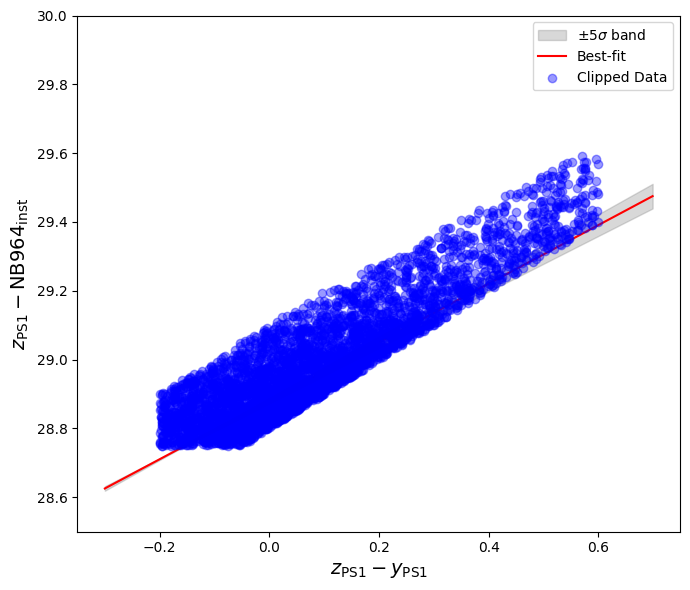

In [49]:
import numpy as np
import pylab as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma
import pandas as pd

# ---------- K-Constant Functions ----------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * np.power(sig, 2.)))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    constant = infinite_integral[0] / definite_integral[0]
    return constant

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ---------- Linear Model ----------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ---------- Sigma Clipping ----------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ---------- Outlier Limits ----------
def bottom_limit(x_val):
    """Lower limit to remove outliers."""
    m = 1
    c = 28.8
    return m * x_val + c

def upper_limit(x_val):
    """Upper limit to remove outliers."""
    m = 1
    c = 29.1
    return m * x_val + c

# ---------- File Paths ----------
# ---------- File Paths ----------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ---------- Constants ----------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ---------- Load Catalogs ----------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ---------- Extract Photometry ----------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ---------- Remove Bad Data ----------
cut = np.where(y != -999)[0]
z, y, n964 = z[cut], y[cut], n964[cut]
z_err, y_err, n964_err = z_err[cut], y_err[cut], n964_err[cut]

# ---------- Compute Colors and Errors ----------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ---------- Apply Color Cuts ----------
cut_x = np.where((delta_pan > -0.2) & (delta_pan < 0.6))[0]
cut_y = np.where((delta_decam > 28.75) & (delta_decam < 29.752))[0]
final_cut = np.intersect1d(cut_x, cut_y)

# ---------- Final Sample ----------
delta_pan = delta_pan[final_cut]
delta_decam = delta_decam[final_cut]
delta_pan_err = delta_pan_err[final_cut]
delta_decam_err = delta_decam_err[final_cut]
delta_decam_err = np.clip(delta_decam_err, MIN_ERR, None)

# ---------- Remove Outliers with Limits ----------
outlier_mask = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[outlier_mask]
delta_decam = delta_decam[outlier_mask]
delta_pan_err = delta_pan_err[outlier_mask]
delta_decam_err = delta_decam_err[outlier_mask]

# ---------- 3-Sigma Clipping + Fit ----------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ---------- Final Linear Fit ----------
popt, pcov = curve_fit(
    straight_line,
    delta_pan_clipped,
    delta_decam_clipped,
    sigma=delta_decam_err_clipped,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

# ---------- Print Fit Results ----------
print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept (zpt):   {popt[1]:.5f} ± {perr[1]:.5f}")

# ---------- K-Correction ----------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ---------- Chi-Square Goodness of Fit ----------
model_vals = straight_line(delta_pan_clipped, *popt)
residuals = delta_decam_clipped - model_vals
chi_squared = np.sum((residuals / delta_decam_err_clipped) ** 2)
dof = len(delta_decam_clipped) - len(popt)
reduced_chi_squared = chi_squared / dof

print(f"\nChi-squared:       {chi_squared:.2f}")
#print(f"DOF:               {dof}")
#print(f"Reduced Chi²:      {reduced_chi_squared:.2f}")

# ---------- Compute Fit & Error Bands ----------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)
popt_up = popt + NSTD * perr
popt_dw = popt - NSTD * perr
fit_up = straight_line(x_fit, *popt_up)
fit_dw = straight_line(x_fit, *popt_dw)

# ---------- Plot ----------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ Error Band
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')

# Best-Fit Line
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)

# Data Points
#plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
            # fmt='o', color='blue', alpha=0.4, label='Clipped Data', zorder=4)
plt.scatter(delta_pan_clipped, delta_decam_clipped, color='blue', alpha=0.4, label='Clipped Data', zorder=4)
print(len(delta_pan_clipped), "data points after clipping.")

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/aishwarya/Documents/Lyman_alpha/CAT/NB964_zpt_fit_with_errorband_outliers_removed.png', dpi=300)
plt.show()


Slope (alpha):     0.85031 ± 0.00847
Intercept at mean x:   28.95779 ± 0.00108

K correction:      -0.15385
ZPT prime:         29.11164


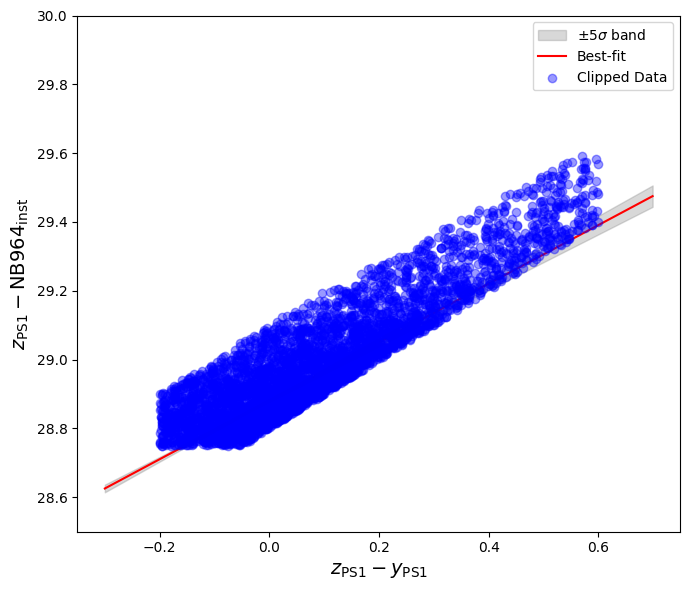

4074 data points after clipping.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Linear Model ------------------------
def straight_line(x, alpha, zpt):
    return alpha * x + zpt

# ------------------------ Sigma Clipping ------------------------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        popt, _ = curve_fit(straight_line, x[mask], y[mask], sigma=yerr[mask], absolute_sigma=True)
        residuals = y - straight_line(x, *popt)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std
    return x[mask], y[mask], yerr[mask], popt

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = y != -999
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ 3-Sigma Clipping ------------------------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, _ = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

# ------------------------ Center x-values ------------------------
x_mean = np.mean(delta_pan_clipped)
x_centered = delta_pan_clipped - x_mean

# ------------------------ Final Linear Fit ------------------------
popt, pcov = curve_fit(
    straight_line, x_centered, delta_decam_clipped,
    sigma=delta_decam_err_clipped, absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))

print(f"Slope (alpha):     {popt[0]:.5f} ± {perr[0]:.5f}")
print(f"Intercept at mean x:   {popt[1]:.5f} ± {perr[1]:.5f}")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = popt[1] - k_const
print(f"\nK correction:      {k_const:.5f}")
print(f"ZPT prime:         {zpt_prime:.5f}")

# ------------------------ Error Band ------------------------
x_fit = np.linspace(x_centered.min() - 0.1, x_centered.max() + 0.1, 200)
fit = straight_line(x_fit, *popt)
popt_up = popt + NSTD * perr
popt_dw = popt - NSTD * perr
fit_up = straight_line(x_fit, *popt_up)
fit_dw = straight_line(x_fit, *popt_dw)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ band
plt.fill_between(x_fit + x_mean, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')

# Best-fit line
plt.plot(x_fit + x_mean, fit, 'r-', label='Best-fit', zorder=3)

# Data points
plt.scatter(delta_pan_clipped, delta_decam_clipped, color='blue', alpha=0.4, label='Clipped Data', zorder=4)

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan_clipped), "data points after clipping.")


Slope (alpha): 0.83424
Line passes through: (0.06095, 28.96540)
K correction: -0.15385
ZPT prime: 29.11925


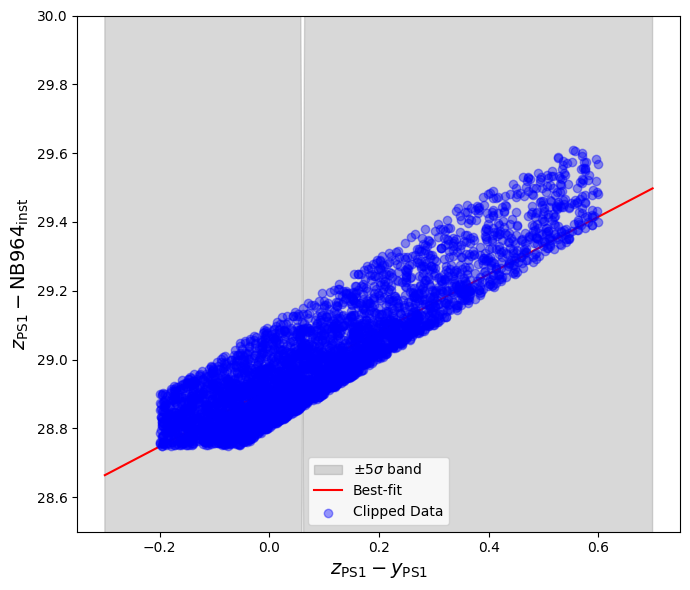

4132 data points after clipping.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Line Through Center ------------------------
def line_through_center(x, alpha, x_mean, y_mean):
    """Line forced to pass through (x_mean, y_mean)"""
    return alpha * (x - x_mean) + y_mean

# ------------------------ Sigma Clipping ------------------------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        x_masked, y_masked, yerr_masked = x[mask], y[mask], yerr[mask]
        x_mean = np.median(x_masked)
        y_mean = np.median(y_masked)

        # Fit slope only, proper curve_fit signature
        def fit_func(x_input, a):
            return line_through_center(x_input, a, x_mean, y_mean)

        popt, _ = curve_fit(fit_func, x_masked, y_masked, sigma=yerr_masked, absolute_sigma=True)
        residuals = y - line_through_center(x, popt[0], x_mean, y_mean)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std

    return x[mask], y[mask], yerr[mask], popt[0], x_mean, y_mean

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = y != -999
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ 3-Sigma Clipping & Fit Through Mean ------------------------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, slope, x_mean, y_mean = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

print(f"Slope (alpha): {slope:.5f}")
print(f"Line passes through: ({x_mean:.5f}, {y_mean:.5f})")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = y_mean - k_const
print(f"K correction: {k_const:.5f}")
print(f"ZPT prime: {zpt_prime:.5f}")

# ------------------------ ±5σ Error Band ------------------------
x_fit = np.linspace(delta_pan_clipped.min()-0.1, delta_pan_clipped.max()+0.1, 200)
fit = line_through_center(x_fit, slope, x_mean, y_mean)

# Simple ±5σ on slope
slope_err = np.std((delta_decam_clipped - y_mean) / (delta_pan_clipped - x_mean))
fit_up = line_through_center(x_fit, slope + NSTD*slope_err, x_mean, y_mean)
fit_dw = line_through_center(x_fit, slope - NSTD*slope_err, x_mean, y_mean)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ band
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')

# Best-fit line
plt.plot(x_fit, fit, 'r-', label='Best-fit', zorder=3)

# Data points
plt.scatter(delta_pan_clipped, delta_decam_clipped, color='blue', alpha=0.4, label='Clipped Data', zorder=4)

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan_clipped), "data points after clipping.")


Slope (alpha): 0.92556 ± 0.00828
Line passes through: (0.09539, 29.01078)
K correction: -0.15385
ZPT prime: 29.16463


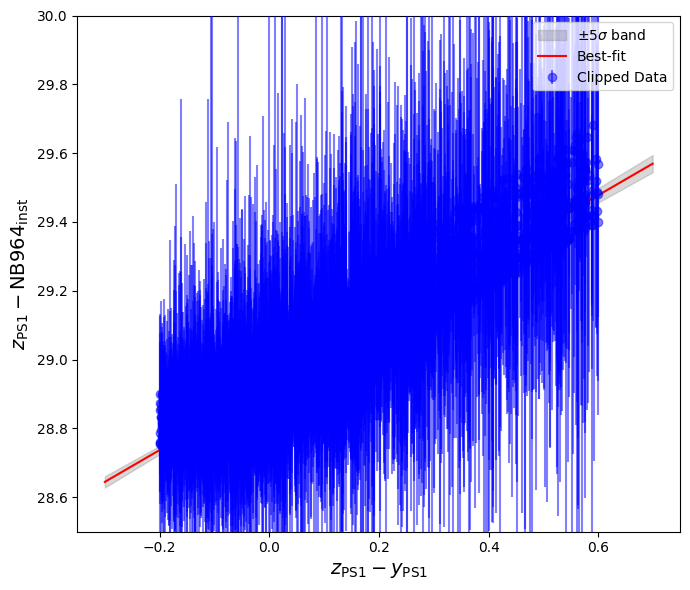

4144 data points after clipping.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Line Through Center ------------------------
def line_through_center(x, alpha, x_mean, y_mean):
    return alpha * (x - x_mean) + y_mean

# ------------------------ Sigma Clipping ------------------------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        x_masked, y_masked, yerr_masked = x[mask], y[mask], yerr[mask]
        x_mean = np.mean(x_masked)
        y_mean = np.mean(y_masked)

        def fit_func(x_input, a):
            return line_through_center(x_input, a, x_mean, y_mean)

        popt, pcov = curve_fit(fit_func, x_masked, y_masked, sigma=yerr_masked, absolute_sigma=True)
        residuals = y - line_through_center(x, popt[0], x_mean, y_mean)
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std

    slope_err = np.sqrt(np.diag(pcov))[0]  # uncertainty in slope
    return x[mask], y[mask], yerr[mask], popt[0], slope_err, x_mean, y_mean

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = y != -999
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ 3-Sigma Clipping & Fit Through Mean ------------------------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, slope, slope_err, x_mean, y_mean = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

print(f"Slope (alpha): {slope:.5f} ± {slope_err:.5f}")
print(f"Line passes through: ({x_mean:.5f}, {y_mean:.5f})")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = y_mean - k_const
print(f"K correction: {k_const:.5f}")
print(f"ZPT prime: {zpt_prime:.5f}")

# ------------------------ ±5σ Error Band (grows linearly) ------------------------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit_line = line_through_center(x_fit, slope, x_mean, y_mean)

# propagate slope uncertainty to get band that grows linearly
fit_up = line_through_center(x_fit, slope + NSTD * slope_err, x_mean, y_mean)
fit_dw = line_through_center(x_fit, slope - NSTD * slope_err, x_mean, y_mean)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ band
plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')

# Best-fit line
plt.plot(x_fit, fit_line, 'r-', label='Best-fit', zorder=3)

# Data points
plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
             fmt='o', color='blue', alpha=0.5, label='Clipped Data', zorder=4)

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan_clipped), "data points after clipping.")


Slope a = 1.09415 ± 0.00897
Intercept b = 28.85742 ± 0.00127
K correction: -0.15385
ZPT′ = b − k = 29.01127


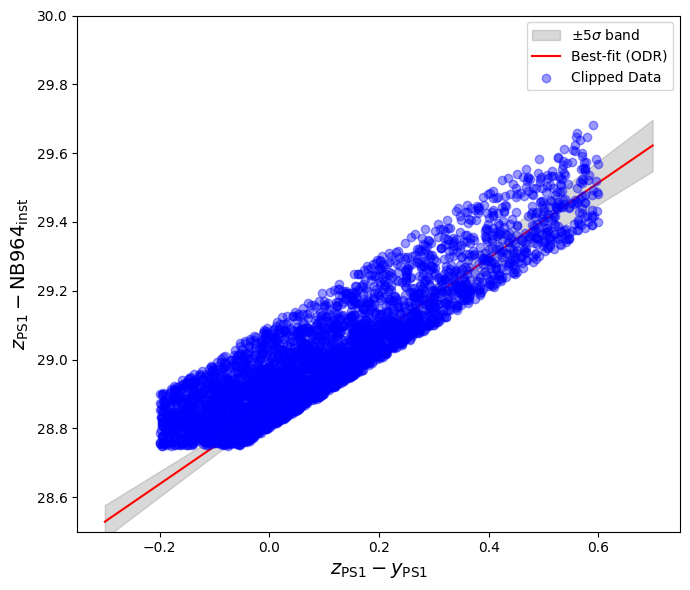

4144 data points after clipping.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import odr
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Limits for Outliers ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = y != -999
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ ODR Linear Fit (with intercept) ------------------------
def linear_func(B, x):
    return B[0] * x + B[1]  # slope * x + intercept

model = odr.Model(linear_func)
data = odr.RealData(delta_pan, delta_decam, sx=delta_pan_err, sy=delta_decam_err)
odr_run = odr.ODR(data, model, beta0=[0.81, 28.9]).run()
a, b = odr_run.beta
sa, sb = odr_run.sd_beta

print(f"Slope a = {a:.5f} ± {sa:.5f}")
print(f"Intercept b = {b:.5f} ± {sb:.5f}")

# ------------------------ K-Correction and ZPT ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = b - k_const
print(f"K correction: {k_const:.5f}")
print(f"ZPT′ = b − k = {zpt_prime:.5f}")

# ------------------------ 1σ Error Band ------------------------
Va, Vb = odr_run.cov_beta[0,0], odr_run.cov_beta[1,1]
Cab = odr_run.cov_beta[0,1]

x_fit = np.linspace(delta_pan.min()-0.1, delta_pan.max()+0.1, 200)
y_fit = a * x_fit + b
y_sigma = np.sqrt((x_fit**2) * Va + Vb + 2 * x_fit * Cab)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# ±5σ band
plt.fill_between(x_fit, y_fit - NSTD*y_sigma, y_fit + NSTD*y_sigma,
                 alpha=0.3, color='gray', label=r'$\pm 5\sigma$ band')

# Best-fit line
plt.plot(x_fit, y_fit, 'r-', label='Best-fit (ODR)', zorder=3)

# Data points
plt.scatter(delta_pan, delta_decam, color='blue', alpha=0.4, label='Clipped Data', zorder=4)

plt.ylim(28.5, 30.0)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan), "data points after clipping.")


Slope a = 1.09415 ± 0.00897
Intercept b = 28.85742 ± 0.00127
K correction: -0.15385
ZPT′ = b − k = 29.01127


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


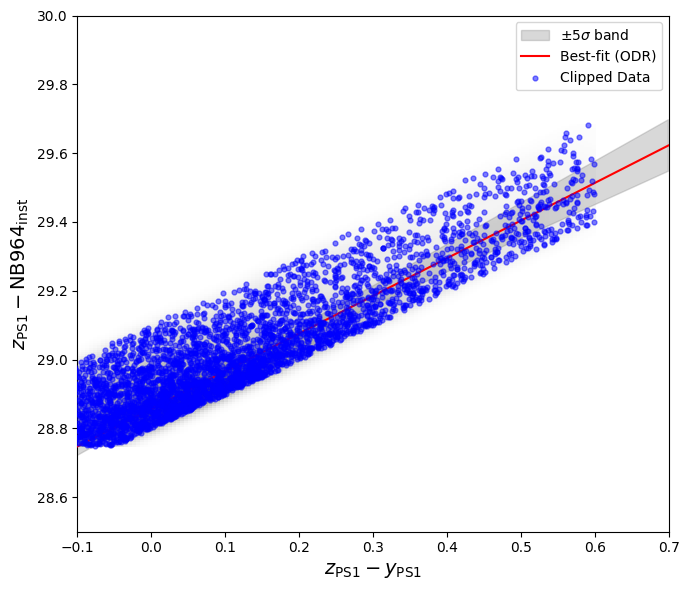

4144 data points after clipping.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import odr
from scipy.integrate import quad
from scipy.stats import gaussian_kde
from astropy.stats import gaussian_fwhm_to_sigma
from pathlib import Path

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    """
    aperture_radius and seeing (FWHM) must be in the same linear units.
    The integral assumes a circularly-symmetric 1D radial profile.
    """
    infinite_integral = quad(gaussian, 0, np.inf, args=(0.0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0.0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Outlier "limits" band ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

def index_in_limits(x, y):
    return (y > bottom_limit(x)) & (y < upper_limit(x))

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam    = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING    = 1.47   # FWHM, same units as aperture radius
NARROW_BAND_APERTURES = 0.94   # radius, same units as seeing
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band
DO_KDE_BACKGROUND = True  # set False to disable KDE background plot

# ------------------------ Load Catalogs ------------------------
# PAN-STARRS CSV
pan = pd.read_csv(NB964_PANSTARRS)

# DECam catalog (.cat) may be comma or whitespace-delimited; try comma first then fallback
decam = None
try:
    decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True, dtype=None, encoding=None)
except Exception:
    decam = np.genfromtxt(NB964_DECam, names=True, dtype=None, encoding=None)

# ------------------------ Extract Photometry ------------------------
# Expecting columns: zPSFMag, yPSFMag, zPSFMagErr, yPSFMagErr in PAN-STARRS
z     = pan['zPSFMag'].to_numpy()
y     = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()

# Expecting MAG_APER, MAGERR_APER in DECam file
n964     = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad/NaN Data ------------------------
mask_valid = (
    (y != -999) &
    np.isfinite(z) & np.isfinite(y) &
    np.isfinite(z_err) & np.isfinite(y_err) &
    np.isfinite(n964) & np.isfinite(n964_err)
)

z, y, z_err, y_err = z[mask_valid], y[mask_valid], z_err[mask_valid], y_err[mask_valid]
n964, n964_err = n964[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan       = z - y                          # z_PS1 - y_PS1
delta_decam     = z - n964                       # z_PS1 - NB964_inst
delta_pan_err   = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
mask_xy = mask_x & mask_y

delta_pan       = delta_pan[mask_xy]
delta_decam     = delta_decam[mask_xy]
delta_pan_err   = delta_pan_err[mask_xy]
delta_decam_err = np.clip(delta_decam_err[mask_xy], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_clip = index_in_limits(delta_pan, delta_decam)
delta_pan       = delta_pan[mask_clip]
delta_decam     = delta_decam[mask_clip]
delta_pan_err   = delta_pan_err[mask_clip]
delta_decam_err = delta_decam_err[mask_clip]

# Safety check: need at least 3 points for ODR
if delta_pan.size < 3:
    raise RuntimeError("Not enough points after clipping to perform ODR.")

# ------------------------ ODR Linear Fit (with intercept) ------------------------
def linear_func(B, x):
    return B[0] * x + B[1]  # slope * x + intercept

model = odr.Model(linear_func)
data  = odr.RealData(delta_pan, delta_decam, sx=delta_pan_err, sy=delta_decam_err)
odr_run = odr.ODR(data, model, beta0=[0.5, 29.0]).run()

a, b   = odr_run.beta
sa, sb = odr_run.sd_beta
print(f"Slope a = {a:.5f} ± {sa:.5f}")
print(f"Intercept b = {b:.5f} ± {sb:.5f}")

# ------------------------ K-Correction and ZPT′ ------------------------
k_const   = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = b - k_const
print(f"K correction: {k_const:.5f}")
print(f"ZPT′ = b − k = {zpt_prime:.5f}")

# ------------------------ 1σ Error Band for the Fit Line ------------------------
Va  = odr_run.cov_beta[0, 0]
Vb  = odr_run.cov_beta[1, 1]
Cab = odr_run.cov_beta[0, 1]

x_fit  = np.linspace(delta_pan.min() - 0.1, delta_pan.max() + 0.1, 400)
y_fit  = a * x_fit + b
y_sig  = np.sqrt((x_fit**2) * Va + Vb + 2 * x_fit * Cab)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

# Optional KDE density background (behind points)
if DO_KDE_BACKGROUND and delta_pan.size > 20:
    nbins = 150
    xy = np.vstack([delta_pan, delta_decam])
    kde = gaussian_kde(xy)
    x_i, y_i = np.mgrid[
        delta_pan.min():delta_pan.max():complex(nbins),
        delta_decam.min():delta_decam.max():complex(nbins)
    ]
    z_i = kde(np.vstack([x_i.ravel(), y_i.ravel()])).reshape(x_i.shape)
    plt.pcolormesh(x_i, y_i, z_i, shading='auto', cmap='gray_r', alpha=0.6)

# ±5σ band
plt.fill_between(x_fit, y_fit - NSTD * y_sig, y_fit + NSTD * y_sig,
                 alpha=0.3, color='gray', label=fr'$\pm {int(NSTD)}\sigma$ band')

# Best-fit line
plt.plot(x_fit, y_fit, 'r-', label='Best-fit (ODR)', zorder=3)

# Data points
plt.scatter(delta_pan, delta_decam, s=12, color='blue', alpha=0.5, label='Clipped Data', zorder=4)

plt.ylim(28.5, 30.0)
plt.xlim(-0.1, 0.7)
plt.legend()
plt.tight_layout()
plt.show()

print(f"{delta_pan.size} data points after clipping.")


Slope (alpha): 0.88696 ± 0.01105
Line passes through: (0.09750, 29.01866)
K correction: -0.15385
ZPT prime (median): 29.00640 ± 0.00146


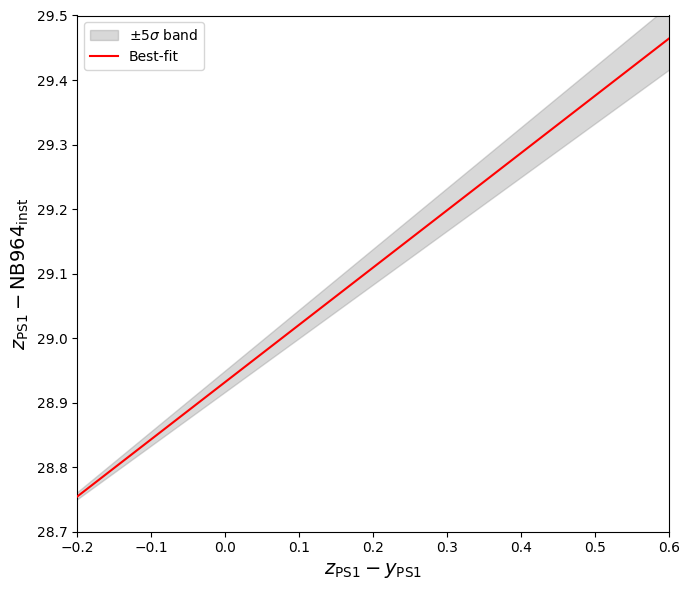

3806 data points after clipping.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Line Through Center ------------------------
def line_through_center(x, alpha, x_mean, y_mean):
    return alpha * (x - x_mean) + y_mean

# ------------------------ Sigma Clipping ------------------------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    popt = [0.0]
    pcov = np.zeros((1,1))
    
    for _ in range(max_iter):
        x_masked, y_masked, yerr_masked = x[mask], y[mask], np.clip(yerr[mask], 1e-5, None)
        x_mean = np.mean(x_masked)
        y_mean = np.mean(y_masked)

        def fit_func(x_input, a):
            return line_through_center(x_input, a, x_mean, y_mean)

        popt, pcov = curve_fit(fit_func, x_masked, y_masked, sigma=yerr_masked, absolute_sigma=True)
        residuals = (y - line_through_center(x, popt[0], x_mean, y_mean)) / yerr
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std

    slope_err = np.sqrt(np.diag(pcov))[0]
    return x[mask], y[mask], yerr[mask], popt[0], slope_err, x_mean, y_mean

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/newcat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = (y != -999) & (z != -999) & (n964 != -999)
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ 3-Sigma Clipping & Fit Through Mean ------------------------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, slope, slope_err, x_mean, y_mean = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

print(f"Slope (alpha): {slope:.5f} ± {slope_err:.5f}")
print(f"Line passes through: ({x_mean:.5f}, {y_mean:.5f})")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = np.median(delta_decam_clipped - slope * (delta_pan_clipped - x_mean))  # median-based ZPT
zpt_err = slope_err * np.median(np.abs(delta_pan_clipped - x_mean))  # approximate
print(f"K correction: {k_const:.5f}")
print(f"ZPT prime (median): {zpt_prime:.5f} ± {zpt_err:.5f}")

# ------------------------ ±5σ Error Band (Growing from Start) ------------------------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit_line = line_through_center(x_fit, slope, x_mean, y_mean)

# Anchor at first point
x0 = x_fit[0]
y0 = line_through_center(x0, slope, x_mean, y_mean)
fit_up = y0 + (slope + NSTD * slope_err) * (x_fit - x0)
fit_dw = y0 + (slope - NSTD * slope_err) * (x_fit - x0)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')
plt.plot(x_fit, fit_line, 'r-', label='Best-fit', zorder=3)
#plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
#            fmt='o', color='blue', alpha=0.5, label='Clipped Data', zorder=4)

plt.ylim(28.7, 29.5)
plt.xlim(-0.2, 0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan_clipped), "data points after clipping.")


Slope (alpha): 0.88964 ± 0.01100
Line passes through: (0.09747, 29.01836)
K correction: -0.15385
ZPT prime (median): 29.00630 ± 0.00147


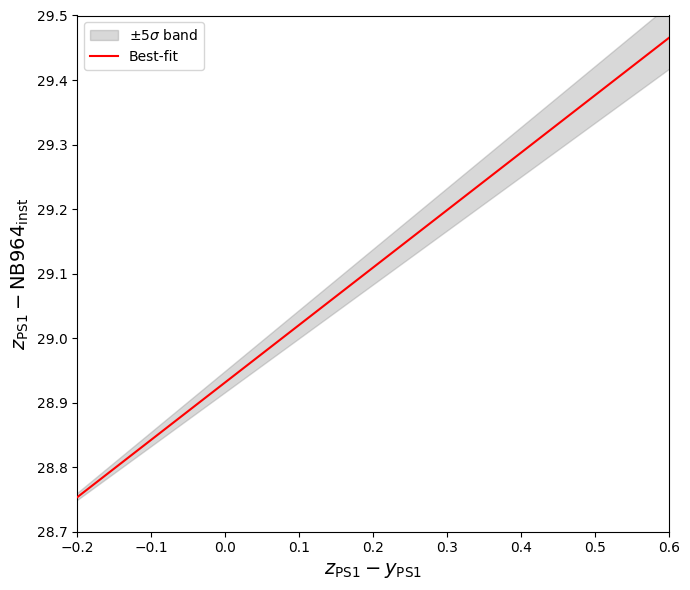

3819 data points after clipping.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Line Through Center ------------------------
def line_through_center(x, alpha, x_mean, y_mean):
    return alpha * (x - x_mean) + y_mean

# ------------------------ Sigma Clipping ------------------------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    popt = [0.0]
    pcov = np.zeros((1,1))
    
    for _ in range(max_iter):
        x_masked, y_masked, yerr_masked = x[mask], y[mask], np.clip(yerr[mask], 1e-5, None)
        x_mean = np.mean(x_masked)
        y_mean = np.mean(y_masked)

        def fit_func(x_input, a):
            return line_through_center(x_input, a, x_mean, y_mean)

        popt, pcov = curve_fit(fit_func, x_masked, y_masked, sigma=yerr_masked, absolute_sigma=True)
        residuals = (y - line_through_center(x, popt[0], x_mean, y_mean)) / yerr
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std

    slope_err = np.sqrt(np.diag(pcov))[0]
    return x[mask], y[mask], yerr[mask], popt[0], slope_err, x_mean, y_mean

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = (y != -999) & (z != -999) & (n964 != -999)
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ 3-Sigma Clipping & Fit Through Mean ------------------------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, slope, slope_err, x_mean, y_mean = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

print(f"Slope (alpha): {slope:.5f} ± {slope_err:.5f}")
print(f"Line passes through: ({x_mean:.5f}, {y_mean:.5f})")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = np.median(delta_decam_clipped - slope * (delta_pan_clipped - x_mean))  # median-based ZPT
zpt_err = slope_err * np.median(np.abs(delta_pan_clipped - x_mean))  # approximate
print(f"K correction: {k_const:.5f}")
print(f"ZPT prime (median): {zpt_prime:.5f} ± {zpt_err:.5f}")

# ------------------------ ±5σ Error Band (Growing from Start) ------------------------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit_line = line_through_center(x_fit, slope, x_mean, y_mean)

# Anchor at first point
x0 = x_fit[0]
y0 = line_through_center(x0, slope, x_mean, y_mean)
fit_up = y0 + (slope + NSTD * slope_err) * (x_fit - x0)
fit_dw = y0 + (slope - NSTD * slope_err) * (x_fit - x0)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')
plt.plot(x_fit, fit_line, 'r-', label='Best-fit', zorder=3)
#plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
#            fmt='o', color='blue', alpha=0.5, label='Clipped Data', zorder=4)

plt.ylim(28.7, 29.5)
plt.xlim(-0.2, 0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan_clipped), "data points after clipping.")


Slope (alpha): 0.88615 ± 0.01119
Line passes through: (0.09696, 29.01770)
K correction: -0.15385
ZPT prime (median): 29.00643 ± 0.00148


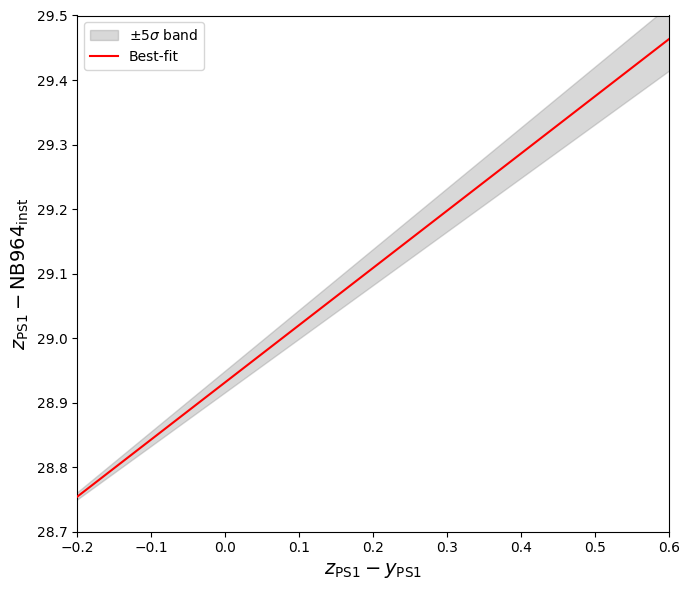

3782 data points after clipping.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Line Through Center ------------------------
def line_through_center(x, alpha, x_mean, y_mean):
    return alpha * (x - x_mean) + y_mean

# ------------------------ Sigma Clipping ------------------------
def sigma_clip_fit(x, y, yerr, sigma=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    popt = [0.0]
    pcov = np.zeros((1,1))
    
    for _ in range(max_iter):
        x_masked, y_masked, yerr_masked = x[mask], y[mask], np.clip(yerr[mask], 1e-5, None)
        x_mean = np.mean(x_masked)
        y_mean = np.mean(y_masked)

        def fit_func(x_input, a):
            return line_through_center(x_input, a, x_mean, y_mean)

        popt, pcov = curve_fit(fit_func, x_masked, y_masked, sigma=yerr_masked, absolute_sigma=True)
        residuals = (y - line_through_center(x, popt[0], x_mean, y_mean)) / yerr
        std = np.std(residuals[mask])
        mask = np.abs(residuals) < sigma * std

    slope_err = np.sqrt(np.diag(pcov))[0]
    return x[mask], y[mask], yerr[mask], popt[0], slope_err, x_mean, y_mean

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = (y != -999) & (z != -999) & (n964 != -999)
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ 3-Sigma Clipping & Fit Through Mean ------------------------
delta_pan_clipped, delta_decam_clipped, delta_decam_err_clipped, slope, slope_err, x_mean, y_mean = sigma_clip_fit(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0
)

print(f"Slope (alpha): {slope:.5f} ± {slope_err:.5f}")
print(f"Line passes through: ({x_mean:.5f}, {y_mean:.5f})")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
zpt_prime = np.median(delta_decam_clipped - slope * (delta_pan_clipped - x_mean))  # median-based ZPT
zpt_err = slope_err * np.median(np.abs(delta_pan_clipped - x_mean))  # approximate
print(f"K correction: {k_const:.5f}")
print(f"ZPT prime (median): {zpt_prime:.5f} ± {zpt_err:.5f}")

# ------------------------ ±5σ Error Band (Growing from Start) ------------------------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 200)
fit_line = line_through_center(x_fit, slope, x_mean, y_mean)

# Anchor at first point
x0 = x_fit[0]
y0 = line_through_center(x0, slope, x_mean, y_mean)
fit_up = y0 + (slope + NSTD * slope_err) * (x_fit - x0)
fit_dw = y0 + (slope - NSTD * slope_err) * (x_fit - x0)

# ------------------------ Plot ------------------------
plt.figure(figsize=(7,6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.fill_between(x_fit, fit_dw, fit_up, color='gray', alpha=0.3, label=r'$\pm 5\sigma$ band')
plt.plot(x_fit, fit_line, 'r-', label='Best-fit', zorder=3)
#plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
#            fmt='o', color='blue', alpha=0.5, label='Clipped Data', zorder=4)

plt.ylim(28.7, 29.5)
plt.xlim(-0.2, 0.6)
plt.legend()
plt.tight_layout()
plt.show()

print(len(delta_pan_clipped), "data points after clipping.")


Slope m: 0.81434 ± 0.01119
Intercept b: 28.89109 ± 0.00159
Cov(m,b): -7.53536e-06
N points after clipping: 3882
x-range after clipping: [-0.200, 0.599] (span 0.799)
Weighted RMS of residuals: 0.09025; dof=3880
Robust intercept (median of y - m x): 28.91997
K correction: -0.15385
ZPT prime (fit): 28.89109 ± 0.00159
ZPT prime (median): 28.91997 ± 0.00135


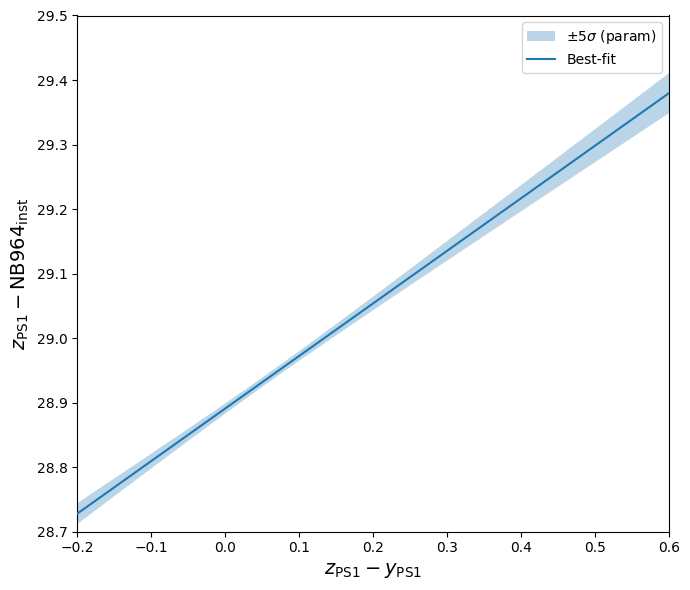

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Linear Model ------------------------
def line(x, m, b):
    return m * x + b

# ------------------------ Sigma-Clipping Linear Fit (m,b) ------------------------
def sigma_clip_fit_mb(x, y, yerr, sigma=3.0, max_iter=10, min_err=1e-5):
    """
    Weighted (by yerr) linear fit with iterative sigma-clipping on normalized residuals.
    Returns:
        x_c, y_c, yerr_c, m, b, cov, rms, dof
    """
    # Ensure finite errors and avoid zeros
    yerr = np.asarray(yerr, float)
    yerr = np.clip(yerr, min_err, None)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
    x, y, yerr = x[mask], y[mask], yerr[mask]

    # Initial fit
    popt, pcov = curve_fit(line, x, y, sigma=yerr, absolute_sigma=True)

    for _ in range(max_iter):
        y_model = line(x, *popt)
        resid = (y - y_model) / yerr
        std = np.std(resid)
        if std == 0 or not np.isfinite(std):
            break
        new_mask = np.abs(resid) < sigma * std

        # If mask didn't change, we're done
        if new_mask.sum() == mask.sum():
            break

        x, y, yerr = x[new_mask], y[new_mask], yerr[new_mask]
        popt, pcov = curve_fit(line, x, y, sigma=yerr, absolute_sigma=True)

    m, b = popt
    # Goodness-of-fit
    y_model = line(x, m, b)
    resid = (y - y_model) / yerr
    dof = max(len(x) - 2, 1)
    rms = np.sqrt(np.mean((y - y_model)**2))
    return x, y, yerr, m, b, pcov, rms, dof

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band from parameter uncertainties

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = np.isfinite(y) & np.isfinite(z) & np.isfinite(n964) & (y != -999) & (z != -999) & (n964 != -999)
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Gross Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ Fit (m, b) with Iterative Sigma Clipping ------------------------
(delta_pan_clipped,
 delta_decam_clipped,
 delta_decam_err_clipped,
 slope, intercept, cov, rms, dof) = sigma_clip_fit_mb(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0, max_iter=10, min_err=MIN_ERR
)

slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])
cov_mb = cov[0, 1]

print(f"Slope m: {slope:.5f} ± {slope_err:.5f}")
print(f"Intercept b: {intercept:.5f} ± {intercept_err:.5f}")
print(f"Cov(m,b): {cov_mb:.5e}")
print(f"N points after clipping: {len(delta_pan_clipped)}")
print(f"x-range after clipping: [{delta_pan_clipped.min():.3f}, {delta_pan_clipped.max():.3f}] "
      f"(span {np.ptp(delta_pan_clipped):.3f})")
print(f"Weighted RMS of residuals: {rms:.5f}; dof={dof}")


# Also compute a robust (median-based) intercept estimate using the fitted slope
b_median = np.median(delta_decam_clipped - slope * delta_pan_clipped)
print(f"Robust intercept (median of y - m x): {b_median:.5f}")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
print(f"K correction: {k_const:.5f}")

# If you want a zeropoint-like term, use intercept (or b_median) directly.
# Here we report both, with intercept uncertainty from covariance.
zpt_prime_fit = intercept
zpt_prime_fit_err = intercept_err

# Robust alternative:
zpt_prime_med = b_median
# For a rough uncertainty on the median-based estimate, use MAD / sqrt(N)
mad = np.median(np.abs((delta_decam_clipped - slope * delta_pan_clipped) - b_median))
zpt_prime_med_err = 1.4826 * mad / np.sqrt(max(len(delta_pan_clipped), 1))

print(f"ZPT prime (fit): {zpt_prime_fit:.5f} ± {zpt_prime_fit_err:.5f}")
print(f"ZPT prime (median): {zpt_prime_med:.5f} ± {zpt_prime_med_err:.5f}")

# ------------------------ Prediction Band from Parameter Uncertainty ------------------------
# Use full covariance to propagate uncertainty in (m, b):
# Var[y_pred(x)] = x^2 Var(m) + Var(b) + 2 x Cov(m,b)
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 300)
y_fit = line(x_fit, slope, intercept)
var_pred = (x_fit**2) * cov[0, 0] + cov[1, 1] + 2.0 * x_fit * cov[0, 1]
# Numerical safety
var_pred = np.clip(var_pred, 0.0, None)
sigma_pred = np.sqrt(var_pred)

fit_up = y_fit + NSTD * sigma_pred
fit_dw = y_fit - NSTD * sigma_pred

# ------------------------ Plot ------------------------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.fill_between(x_fit, fit_dw, fit_up, alpha=0.3, label=fr'$\pm {int(NSTD)}\sigma$ (param)')
plt.plot(x_fit, y_fit, label='Best-fit', zorder=3)

# If you want points with errorbars, uncomment:
# plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
#              fmt='o', alpha=0.6, label='Clipped data', zorder=4)

plt.ylim(28.7, 29.5)
plt.xlim(-0.2, 0.6)
plt.legend()
plt.tight_layout()
plt.show()


Slope m: 0.81434 ± 0.01119
Intercept b: 28.89109 ± 0.00159
Cov(m,b): -7.53536e-06
N points after clipping: 3882
x-range after clipping: [-0.200, 0.599] (span 0.799)
Weighted RMS of residuals: 0.09025; dof=3880
Robust intercept (median of y - m x): 28.91997
K correction: -0.15385
ZPT prime (fit): 28.89109 ± 0.00159
ZPT prime (median): 28.91997 ± 0.00135


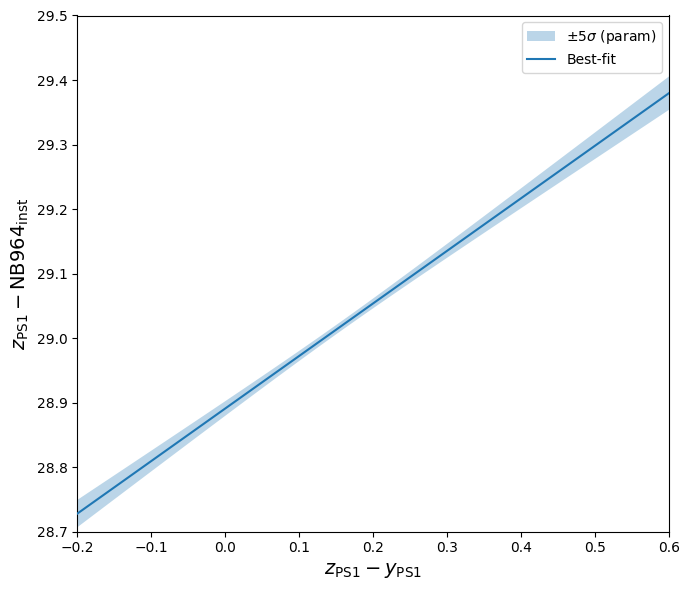

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad
from astropy.stats import gaussian_fwhm_to_sigma

# ------------------------ K-Constant Functions ------------------------
def gaussian(x_array: np.ndarray, mean: float, fwhm: float):
    sig = fwhm * gaussian_fwhm_to_sigma
    return np.exp(-np.power(x_array - mean, 2.) / (2 * sig**2))

def calculate_k_constant(aperture_radius: float, seeing: float):
    infinite_integral = quad(gaussian, 0, np.inf, args=(0, seeing))
    definite_integral = quad(gaussian, 0, aperture_radius, args=(0, seeing))
    return infinite_integral[0] / definite_integral[0]

def calculate_k_constant_mag(aperture_radius: float, seeing: float) -> float:
    k_constant = calculate_k_constant(aperture_radius, seeing)
    return -2.5 * np.log10(k_constant)

# ------------------------ Linear Model ------------------------
def line(x, m, b):
    return m * x + b

# ------------------------ Sigma-Clipping Linear Fit (m,b) ------------------------
def sigma_clip_fit_mb(x, y, yerr, sigma=3.0, max_iter=10, min_err=1e-5):
    """
    Weighted (by yerr) linear fit with iterative sigma-clipping on normalized residuals.
    Returns:
        x_c, y_c, yerr_c, m, b, cov, rms, dof
    """
    # Ensure finite errors and avoid zeros
    yerr = np.asarray(yerr, float)
    yerr = np.clip(yerr, min_err, None)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
    x, y, yerr = x[mask], y[mask], yerr[mask]

    # Initial fit
    popt, pcov = curve_fit(line, x, y, sigma=yerr, absolute_sigma=True)

    for _ in range(max_iter):
        y_model = line(x, *popt)
        resid = (y - y_model) / yerr
        std = np.std(resid)
        if std == 0 or not np.isfinite(std):
            break
        new_mask = np.abs(resid) < sigma * std

        # If mask didn't change, we're done
        if new_mask.sum() == mask.sum():
            break

        x, y, yerr = x[new_mask], y[new_mask], yerr[new_mask]
        popt, pcov = curve_fit(line, x, y, sigma=yerr, absolute_sigma=True)

    m, b = popt
    # Goodness-of-fit
    y_model = line(x, m, b)
    resid = (y - y_model) / yerr
    dof = max(len(x) - 2, 1)
    rms = np.sqrt(np.mean((y - y_model)**2))
    return x, y, yerr, m, b, pcov, rms, dof

# ------------------------ Outlier Limits ------------------------
def bottom_limit(x_val):
    return x_val + 28.8

def upper_limit(x_val):
    return x_val + 29.1

# ------------------------ File Paths ------------------------
NB964_PANSTARRS = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_panstarrs_matched.csv'
NB964_DECam = '/Users/aishwarya/Documents/Lyman_alpha/CAT/New_cat/n964_band_decam_matched.cat'

# ------------------------ Constants ------------------------
MAG_ZEROPOINT = 0.0
NARROW_BAND_SEEING = 1.47
NARROW_BAND_APERTURES = 0.94
MIN_ERR = 0.01
NSTD = 5.0  # ±5σ band from parameter uncertainties

# ------------------------ Load Catalogs ------------------------
decam = np.genfromtxt(NB964_DECam, delimiter=',', names=True)
pan = pd.read_csv(NB964_PANSTARRS)

# ------------------------ Extract Photometry ------------------------
z = pan['zPSFMag'].to_numpy()
y = pan['yPSFMag'].to_numpy()
z_err = pan['zPSFMagErr'].to_numpy()
y_err = pan['yPSFMagErr'].to_numpy()
n964 = decam['MAG_APER'] + MAG_ZEROPOINT
n964_err = decam['MAGERR_APER']

# ------------------------ Remove Bad Data ------------------------
mask_valid = np.isfinite(y) & np.isfinite(z) & np.isfinite(n964) & (y != -999) & (z != -999) & (n964 != -999)
z, y, n964 = z[mask_valid], y[mask_valid], n964[mask_valid]
z_err, y_err, n964_err = z_err[mask_valid], y_err[mask_valid], n964_err[mask_valid]

# ------------------------ Compute Colors and Errors ------------------------
delta_pan = z - y
delta_decam = z - n964
delta_pan_err = np.hypot(z_err, y_err)
delta_decam_err = np.hypot(z_err, n964_err)

# ------------------------ Apply Color Cuts ------------------------
mask_x = (delta_pan > -0.2) & (delta_pan < 0.6)
mask_y = (delta_decam > 28.75) & (delta_decam < 29.752)
final_mask = mask_x & mask_y

delta_pan = delta_pan[final_mask]
delta_decam = delta_decam[final_mask]
delta_pan_err = delta_pan_err[final_mask]
delta_decam_err = np.clip(delta_decam_err[final_mask], MIN_ERR, None)

# ------------------------ Remove Gross Outliers with Limits ------------------------
mask_outliers = (delta_decam > bottom_limit(delta_pan)) & (delta_decam < upper_limit(delta_pan))
delta_pan = delta_pan[mask_outliers]
delta_decam = delta_decam[mask_outliers]
delta_pan_err = delta_pan_err[mask_outliers]
delta_decam_err = delta_decam_err[mask_outliers]

# ------------------------ Fit (m, b) with Iterative Sigma Clipping ------------------------
(delta_pan_clipped,
 delta_decam_clipped,
 delta_decam_err_clipped,
 slope, intercept, cov, rms, dof) = sigma_clip_fit_mb(
    delta_pan, delta_decam, delta_decam_err, sigma=3.0, max_iter=10, min_err=MIN_ERR
)

slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])
cov_mb = cov[0, 1]

print(f"Slope m: {slope:.5f} ± {slope_err:.5f}")
print(f"Intercept b: {intercept:.5f} ± {intercept_err:.5f}")
print(f"Cov(m,b): {cov_mb:.5e}")
print(f"N points after clipping: {len(delta_pan_clipped)}")
print(f"x-range after clipping: [{delta_pan_clipped.min():.3f}, {delta_pan_clipped.max():.3f}] "
      f"(span {np.ptp(delta_pan_clipped):.3f})")
print(f"Weighted RMS of residuals: {rms:.5f}; dof={dof}")

# Also compute a robust (median-based) intercept estimate using the fitted slope
b_median = np.median(delta_decam_clipped - slope * delta_pan_clipped)
print(f"Robust intercept (median of y - m x): {b_median:.5f}")

# ------------------------ K-Correction ------------------------
k_const = calculate_k_constant_mag(NARROW_BAND_APERTURES, NARROW_BAND_SEEING)
print(f"K correction: {k_const:.5f}")

# Zeropoint-like terms
zpt_prime_fit = intercept
zpt_prime_fit_err = intercept_err
zpt_prime_med = b_median
mad = np.median(np.abs((delta_decam_clipped - slope * delta_pan_clipped) - b_median))
zpt_prime_med_err = 1.4826 * mad / np.sqrt(max(len(delta_pan_clipped), 1))

print(f"ZPT prime (fit): {zpt_prime_fit:.5f} ± {zpt_prime_fit_err:.5f}")
print(f"ZPT prime (median): {zpt_prime_med:.5f} ± {zpt_prime_med_err:.5f}")

# ------------------------ Prediction Band from Parameter Uncertainty ------------------------
x_fit = np.linspace(delta_pan_clipped.min() - 0.1, delta_pan_clipped.max() + 0.1, 300)
y_fit = line(x_fit, slope, intercept)

# ✅ Anchor at pivot point
x_pivot = np.mean(delta_pan_clipped)
dx = x_fit - x_pivot
var_pred = (dx**2) * cov[0, 0] + cov[1, 1] + 2.0 * dx * cov[0, 1]
var_pred = np.clip(var_pred, 0.0, None)
sigma_pred = np.sqrt(var_pred)

fit_up = y_fit + NSTD * sigma_pred
fit_dw = y_fit - NSTD * sigma_pred

# ------------------------ Plot ------------------------
plt.figure(figsize=(7, 6))
plt.xlabel(r'$z_{\rm PS1} - y_{\rm PS1}$', fontsize=14)
plt.ylabel(r'$z_{\rm PS1} - {\rm NB964}_{\rm inst}$', fontsize=14)

plt.fill_between(x_fit, fit_dw, fit_up, alpha=0.3, label=fr'$\pm {int(NSTD)}\sigma$ (param)')
plt.plot(x_fit, y_fit, label='Best-fit', zorder=3)

# Uncomment to see data points
# plt.errorbar(delta_pan_clipped, delta_decam_clipped, yerr=delta_decam_err_clipped,
#              fmt='o', alpha=0.6, label='Clipped data', zorder=4)

plt.ylim(28.7, 29.5)
plt.xlim(-0.2, 0.6)
plt.legend()
plt.tight_layout()
plt.show()
